<a href="https://colab.research.google.com/github/cyeef/Data-Science-Portfolio-C21-/blob/main/Projects/Census_Regression_Bayes_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Business problem - determine if a Gaussian Naive Bayes or Regression Model project will align with what "is to come" in the bootcamp.  The data is from the Vincent Index Rdataset and focuses on the US Census data


Will do a regression model on total_persoanl_income will be **'y'** the *target value.*  The 'y' target is continous data not classification like a catagory of things.  

In [22]:
import pandas as pd
from rich import print

In [2]:
census = pd.read_csv("https://vincentarelbundock.github.io/Rdatasets/csv/openintro/census.csv")

print("[bold blue]shape: [/bold blue]", census.shape)
census.head()

shape: 
(500, 9)

,rownames,census_year,state_fips_code,total_family_income,age,sex,race_general,marital_status,total_personal_income
0,1,2000,Florida,14550.0,44,Male,Two major races,Married/spouse present,0.0
1,2,2000,Florida,22800.0,20,Female,White,Never married/single,13000.0
2,3,2000,Florida,0.0,20,Male,Black,Never married/single,20000.0
3,4,2000,Florida,23000.0,6,Female,White,Never married/single,NaN
4,5,2000,Florida,48000.0,55,Male,White,Married/spouse present,36000.0


In [3]:
census.tail()


,rownames,census_year,state_fips_code,total_family_income,age,sex,race_general,marital_status,total_personal_income
495,496,2000,Virginia,8500.0,68,Female,White,Divorced,8500.0
496,497,2000,Virginia,55400.0,12,Male,White,Never married/single,NaN
497,498,2000,Virginia,15000.0,60,Male,Black,Widowed,15000.0
498,499,2000,Virginia,NaN,60,Male,Black,Married/spouse absent,48600.0
499,500,2000,Virginia,39370.0,47,Male,White,Married/spouse present,19800.0


In [4]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=census)

https://docs.google.com/spreadsheets/d/1xc7R6jb7AgjSH_nlheqib9e9X9SFqbYYSO-ZhwFYXy4/edit#gid=0


Check null count per column and total null count.

In [5]:
print(census.isnull().sum())   # null count per column

rownames                   0
census_year                0
state_fips_code            0
total_family_income       15
age                        0
sex                        0
race_general               0
marital_status             0
total_personal_income    108
dtype: int64

In [6]:
print(census.isnull().sum().sum())

123

Dropping nulls for non earners; children with no income.  

In [7]:
# keep only rows that HAVE a personal income value
earners = census[census["total_personal_income"].notnull()].copy()  # mask and gives a true value to every row has income and dropping non earners 108 total

print("[bold blue]after dropping null personal income: [/bold blue]", earners.shape)
print("[bold red]remaining nulls:\n [/bold red]", earners.isnull().sum())

after dropping null personal income: 
(392, 9)

remaining nulls:
  rownames                  0
census_year               0
state_fips_code           0
total_family_income      15
age                       0
sex                       0
race_general              0
marital_status            0
total_personal_income     0
dtype: int64

Showing evidence of non earner count

In [8]:
dropped = census[census["total_personal_income"].isnull()]  # showing non earner count - mean age 6.7 and min age 0 and max 14.00
print("[bold blue]non-earner count: [/bold blue]", len(dropped)) # this is not missing values but non applicable to income earners
print(dropped["age"].describe())
print("under 16:", (dropped["age"] < 16).sum())

non-earner count:  108

count    108.000000
mean       6.796296
std        3.756015
min        0.000000
25%        4.000000
50%        6.000000
75%       10.000000
max       14.000000
Name: age, dtype: float64

under 16: 108

Drop adult non earners for a cleaner data set, although loosing 52 rows of non earners - we will not distort the regression model with the zeros.  These non earners are working age people.

In [9]:
zeros = earners[earners["total_personal_income"] == 0]
print("count:", len(zeros))
print(zeros["age"].describe())
print(zeros["marital_status"].value_counts())
print("supported by family income:", (zeros["total_family_income"] > 0).sum())

count: 52

count    52.000000
mean     36.500000
std      18.820619
min      15.000000
25%      17.750000
50%      36.000000
75%      49.250000
max      87.000000
Name: age, dtype: float64

marital_status
Married/spouse present    21
Never married/single      21
Widowed                    5
Divorced                   2
Married/spouse absent      2
Separated                  1
Name: count, dtype: int64

supported by family income: 42


Ensuring all non-earner values from dataset, making a copy of DataFrame leaving only earners. Will impute median income in the eleven remaining adults who earn but have no recorded family income reported.


In [10]:

# non-earner = no POSITIVE personal income (covers null children AND zero-income adults)
earners = census[(census["total_personal_income"].notnull())
                 & (census["total_personal_income"] > 0)].copy()

print("after dropping non-earners:", earners.shape)
print("remaining nulls:\n", earners.isnull().sum())

after dropping non-earners:
(339, 9)

remaining nulls:
 rownames                  0
census_year               0
state_fips_code           0
total_family_income      11
age                       0
sex                       0
race_general              0
marital_status            0
total_personal_income     0
dtype: int64

In [11]:
print(earners.isnull().sum().sum())

11

Impute median values into the unreported earning rows.

In [12]:
fam_median = earners["total_family_income"].median()
print("[bold blue]filling 11 nulls with median: [/bold blue]", fam_median)

earners["total_family_income"] = earners["total_family_income"].fillna(fam_median)

print("[bold red]remaining nulls: [/bold red]", earners.isnull().sum().sum())   # expect 0

filling 11 nulls with median:  44455.0

remaining nulls:  0

Dropping 'total_personal_income, rownames and census_year from the data set.  

In [13]:

y = earners["total_personal_income"]

X = earners.drop(columns=["total_personal_income", "rownames", "census_year"])

print("[bold blue]Target y: [/bold blue]", y.name, "| range:", y.min(), "to", y.max())
print("[bold red]Features X: [/bold red]", list(X.columns))
print(X.dtypes)

Target y:  total_personal_income | range: 10.0 to 456000.0

Features X: 
['state_fips_code', 'total_family_income', 'age', 'sex', 'race_general', 'marital_status']

state_fips_code         object
total_family_income    float64
age                      int64
sex                     object
race_general            object
marital_status          object
dtype: object

One hot encoding to turn values into 0/1 and avoiding false ordinal assignment.  Regression models operate on coefficient values and turning nominal data into ordinal values would assign a false order to features like 'widowed' assigning a ordinal 5 would make the model select for a higher value than say divorced or married at ordinal 2 and 3 which would be false because the data is not assignment of rank order (less to great).  use pd.get_dummies

In [14]:
X_encoded = pd.get_dummies(X, drop_first=True)
print("before:", X.shape, "→ after:", X_encoded.shape)

before:
(339, 6)
→ after:
(339, 58)

To avoid overfitting will drop the 'state_fips_code' - one hot coding got rid of the columns name and increased column names to 45 from that row, and each column had 2-3 people under the new column name. Getting a pattern from the data will cause the model to overfit these data points and over represent the values in the coefficients.

In [15]:
y = earners["total_personal_income"]

# drop target + dead columns + state
X = earners.drop(columns=["total_personal_income", "rownames",
                          "census_year", "state_fips_code"])

X_encoded = pd.get_dummies(X, drop_first=True)
print("[bold blue]features: [/bold blue]", X_encoded.shape)  #reduced columns from 58 above to 15 features of x

features: 
(339, 15)

Train/test split best practice 80% train and 20% test.  The reason is to train the model on data it has not seen to avoid 'memorization' and selection for the same values in training (overfitting).  This is important to see if prediction on values is learning or just memorization on the data.

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

print("[bold blue]train:[/bold blue]", X_train.shape[0], "rows | [bold red]test:[/bold red]", X_test.shape[0], "rows")

train: 271 rows | test: 68 rows

Testing for prediction or memorization.  R2 values suggest predictions not memorization if R2 = 1 a perfect prediction, if R2 = 0 it is no better than a guess. Output shows Train was at 0.725 and Test was at 0.435 a significant distance between test and train, some overfitting shown by the gap 0.29 in the R2 test and train scores.

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

model = LinearRegression()
model.fit(X_train, y_train)

print("Train R²:", round(model.score(X_train, y_train), 3))
print("Test  R²:", round(model.score(X_test, y_test), 3))

rmse = np.sqrt(mean_squared_error(y_test, model.predict(X_test)))
print("Test RMSE: $", round(rmse))

Train R²: 0.725

Test  R²: 0.435

Test RMSE: $ 18827

Running np.log because data is positvley skewed and for a balanced regression model we should have a evenly distributed curve for the target or close to it to improve prediction rates that are not guesses.  5.55 was postive skew and we now have -1.45 skew so the distribution went negetive so no balance on y taget.  The gap is smaler than then the baseline 0.24 but the train and test values decreased - overfitting was lowered in log output - showing log did not make y symetrical, we will keep baseline and reject log transformation.

In [18]:


# check for the the log transformation skew
y_log = np.log(y)
print("skew before:", round(y.skew(), 2), "→ after:", round(y_log.skew(), 2))

# refit on log target, same split (random_state=42)
Xtr, Xte, ytr, yte = train_test_split(X_encoded, y_log, test_size=0.2, random_state=42)
log_model = LinearRegression().fit(Xtr, ytr)
print("Train R²:", round(log_model.score(Xtr, ytr), 3))
print("Test  R²:", round(log_model.score(Xte, yte), 3))

skew before: 5.55 → after: -1.45

Train R²: 0.313

Test  R²: 0.069

Will use LassoCV in the following code block, tunes the alpha automatically for cross validation, drops noise, may loose some features but see improvement in the prediction, train/test.

Above the test scores still have a overfit train 0.29 gap between Baseline scores train/test data, and from log test 0.24 gap which is an improvement compared to baseline scores. Gap scores can improve but if R2 scores get smaller the machine is just guessing.

In [19]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()   #  # turning values to mean 0 and std to 1 to normalize the data - reduce variations in coefficients
Xtr_s = scaler.fit_transform(X_train)    # learns from training data only
Xte_s = scaler.transform(X_test)  # applies output to the test data so test data is not effected by the scaling

lasso = LassoCV(cv=5, random_state=42, max_iter=10000)  # checking for the alpha and determining the  best alpha for the data set
lasso.fit(Xtr_s, y_train)

print("chosen alpha:", round(lasso.alpha_, 2))
print("Train R²:", round(lasso.score(Xtr_s, y_train), 3))
print("Test  R²:", round(lasso.score(Xte_s, y_test), 3))

chosen alpha: 4264.83

Train R²: 0.688

Test  R²: 0.582

Checking the lasso gaps

In [20]:
print("Lasso gap:", round(lasso.score(Xtr_s, y_train) - lasso.score(Xte_s, y_test), 3))

Lasso gap: 0.106

Compared to baseline (**train 0.725 / test 0.435, gap 0.29**) and log (**train
0.313 / test 0.069, gap 0.24**),

Lasso scored **train 0.688 / test 0.582, gap 0.106**. The gap is smaller improving the prediction ability and reducing memorization/guessing.


**Utilizing Gaussian Naive Bayes to classify income as a categorical target classifier.**

In [ ]:
print(earners.columns.tolist())  # checking on names for earners

In [24]:
# drop non-earners and clean
earners = census[(census["total_personal_income"].notnull()) & (census["total_personal_income"] > 0)].copy()
earners["total_family_income"] = earners["total_family_income"].fillna(earners["total_family_income"].median())



In [25]:
#create the income bands
earners["income_band"] = pd.qcut(earners["total_personal_income"], q=3, labels=["Low","Medium","High"])



In [26]:
# 3. confirm it's there now
print(earners.columns.tolist())

[
    'rownames',
    'census_year',
    'state_fips_code',
    'total_family_income',
    'age',
    'sex',
    'race_general',
    'marital_status',
    'total_personal_income',
    'income_band'
]

Creating y target 'income_band', dropping it from X features as 'total_personal_income' and removing columns; rownames, census_year, state_fips_code - this was done in regression modeling.

In [27]:
y_bayes = earners["income_band"] # creates categories 'low, medium, and high
X_bayes = earners.drop(columns=["total_personal_income", "income_band",
                                "rownames", "census_year", "state_fips_code"])  # drops target out of x and removes the rest.
X_bayes_encoded = pd.get_dummies(X_bayes, drop_first=True)  # creating same features as in regression.

print("y classes:", y_bayes.unique().tolist())
print("X shape:", X_bayes_encoded.shape)

y classes:
['Low', 'Medium', 'High']

X shape:
(339, 15)

Creating proportional representation for each class in the data set for Low, Medium and High (balancing). Use stratify=y_bayes not used in regression..

In [28]:
Xtr_b, Xte_b, ytr_b, yte_b = train_test_split(
    X_bayes_encoded, y_bayes, test_size=0.2, random_state=42, stratify=y_bayes
)

Normal distribution in 'y'.

In [29]:
print("train:", ytr_b.value_counts().to_dict())
print("test :", yte_b.value_counts().to_dict())

train:
{'High': 91, 'Low': 90, 'Medium': 90}

test :
{'Low': 23, 'Medium': 23, 'High': 22}

Fit GNB + score, looking for overfitting, and accuracy in the prediction. FI scores indicate that the model is doing well in predicting income for low earners but High and Medium earners are not so accurate, the current model may default to the low scores - guessing/memorizing. Will look at features to see where the overlap is happening - the model may be distugishing to catagories Medium and High based upon one feature and not getting a clear distinction between the two.

In [30]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report

gnb = GaussianNB()
gnb.fit(Xtr_b, ytr_b)

print("Train accuracy:", round(gnb.score(Xtr_b, ytr_b), 3))
print("Test  accuracy:", round(gnb.score(Xte_b, yte_b), 3))
print(classification_report(yte_b, gnb.predict(Xte_b)))

Train accuracy: 0.472

Test  accuracy: 0.412

precision    recall  f1-score   support

        High       1.00      0.14      0.24        22
         Low       0.44      0.91      0.59        23
      Medium       0.24      0.17      0.20        23

    accuracy                           0.41        68
   macro avg       0.56      0.41      0.34        68
weighted avg       0.55      0.41      0.35        68

In [37]:
# Cross validation
from sklearn.model_selection import cross_val_score

scores = cross_val_score(GaussianNB(), X_bayes_encoded, y_bayes, cv=5)
print("CV accuracy per fold:", scores.round(3))
print("Mean CV accuracy:", round(scores.mean(), 3))

CV accuracy per fold: [0.441 0.456 0.471 0.485 0.418]

Mean CV accuracy: 0.454

Confusion Matrix

In [31]:
from sklearn.metrics import confusion_matrix

preds = gnb.predict(Xte_b)   # use your fitted model's name here

labels = ["Low", "Medium", "High"]
cm = confusion_matrix(yte_b, preds, labels=labels)

cm_df = pd.DataFrame(cm,
                     index=[f"actual_{l}" for l in labels],
                     columns=[f"pred_{l}" for l in labels])
print(cm_df)

pred_Low  pred_Medium  pred_High
actual_Low           21            2          0
actual_Medium        19            4          0
actual_High           8           11          3

Actual low was
  ,

1. 21 that is correct
2. Actual low was 2 but it predicted medium - wrong
3. Did not fail on high 0

Actual medium

1. was 19 but it predicted low - wrong
2. actual medium was 4 predicted 4 was right
3. did not fail on high 0

Actual high

1. was 8 but it predicted low - wrong
2. actual high was 11 but predicted medium - wrong
3. actual high was 3 predicted high - right








     ,

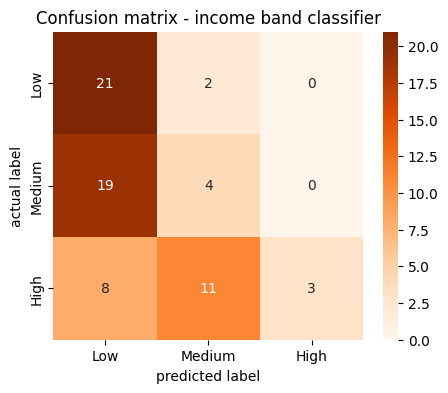

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(yte_b, preds, labels=["Low","Medium","High"])

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges",
            xticklabels=["Low","Medium","High"],
            yticklabels=["Low","Medium","High"])
plt.xlabel("predicted label")
plt.ylabel("actual label")
plt.title("Confusion matrix - income band classifier")
plt.show()

# Summary

### Cleaning
Started with 500 rows and 9 columns dropped 108 rows that related to children and the no value of earning annotated - this was not a null value.

Dropped 52 working age adults because they had 0 income, wanted to keep a positively skewed target set.

Median filled 11 remaining null values from rows that were not filled for some reason - skew was mean $58,953 and median was $44,455.

Final row count was 339 and 0 nulls.
Started with 500 rows and 9 columns dropped 108 rows that related to children and the no value of earning annotated - this was not a null value.

Dropped 52 working age adults because they had 0 income, wanted to keep a positively skewed target set.

Median filled 11 remaining null values from rows that were not filled for some reason skew was mean 58953 and median was 44455.

Final row count was 339 and 0 nulls.

### Regression - target: total_personal_ income, continous
One-hot encode features and dropped state_fips_code to reduce overfitting risk, some states had more categories than values in the new columns.

Baseline LinearRegression: Train R2 0.725 / Test R2 0.435, gap 0.29 -
mild overfitting.

Log transforming target not accepted due to R2 falling to 0.069.

LassoCV auto tuned alpha produced better results, Test R2 increased to 0.688, Train R2 increased to 0.582, reduced the gap between the Test and Train = .106 increasing the modeling prediction ability.  Lasso CV was the final model.

### Classification target: income_band - LOW/MEDIUM/HIGH
Utilized same data set, 339 rows and 0 nulls

GaussianNB Train accuracy 0.472 / Test accuracy 0.412 beats random
guessing at 0.333.

Used cross validation to see if 0.412 accuracy is stable within the data set - done with LassoCV but doing so for best practice. Model is relatively accurate across 5 folds of testing CV accuracy per fold: [0.441 0.456 0.471 0.485 0.418]
Mean CV accuracy: 0.454 above 0.333 gues range so prediction is good.


The GNB showed biased in predicting low income far more than any category - this may be because high earners and medium earners cannot be distinguished by the model.  Further investigation is pending.

## Final conclusion Produced By Claude AI

LassoCV improved the regression by removing weak features (58 -> 15 ->
effectively 4 nonzero coefficients), not by reducing the number of rows.
The surviving features: total_family_income (by far the strongest
predictor, coefficient ~37,672), age (~755), sex_Male (~4,427), and one
race category. Holding other factors constant, this model predicts men
earn about $4,427 more than women in this sample - a real but secondary
effect next to family income.

Bayes (GaussianNB) did not improve with cross-validation - CV confirmed
its ~0.41-0.45 accuracy is STABLE across different data splits, not that
the model got better. It remains a modest classifier, biased toward
predicting "Low" income.

Caveat: this is a correlational finding from 339 people in a 2000 census
sample via a linear model - not a causal or general claim about earnings.